# Mixed Dataset Analysis

Analysis of the mixed dataset combining numbers and synthetic menu data.

**What this checks:**
1. Source distribution (numbers vs synthetic)
2. Split distribution and balance
3. Field type composition
4. Style leakage (critical)
5. Format diversity
6. Image quality
7. Visual samples from both sources

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Mixed Dataset

In [2]:
dataset_dir = Path('dataset_mixed')
manifest_path = dataset_dir / 'manifest.csv'

df = pd.read_csv(manifest_path)
print(f"Total samples: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Total samples: 1210

Columns: ['crop_path', 'text', 'split', 'field_type', 'style_id', 'bias', 'source', 'category', 'vocab_bucket']


,crop_path,text,split,field_type,style_id,bias,source,category,vocab_bucket
0,crops/mixed_01164.png,9.84 DT,train,price,8,0.940,synthetic,Coffee,train
1,crops/mixed_00212.png,16.000,train,price,3,0.823,numbers,NaN,NaN
2,crops/mixed_00464.png,"4,50",train,price,10,0.770,numbers,NaN,NaN
3,crops/mixed_00560.png,50.00,train,price,9,0.605,numbers,NaN,NaN
4,crops/mixed_01296.png,Ginger Beer,train,name,0,0.410,synthetic,Soft Drinks,train
5,crops/mixed_00066.png,10.50,train,price,9,0.568,numbers,NaN,NaN
6,crops/mixed_00502.png,42,val,price,6,0.453,numbers,NaN,NaN
7,crops/mixed_00427.png,35,train,price,4,0.487,numbers,NaN,NaN
8,crops/mixed_00540.png,"5,00",test,price,7,0.509,numbers,NaN,NaN
9,crops/mixed_00402.png,"30,00",train,price,9,0.724,numbers,NaN,NaN


## 2. Source Distribution (Numbers vs Synthetic)

SOURCE DISTRIBUTION
source
numbers      894
synthetic    316
Name: count, dtype: int64

Numbers:   73.9%
Synthetic: 26.1%


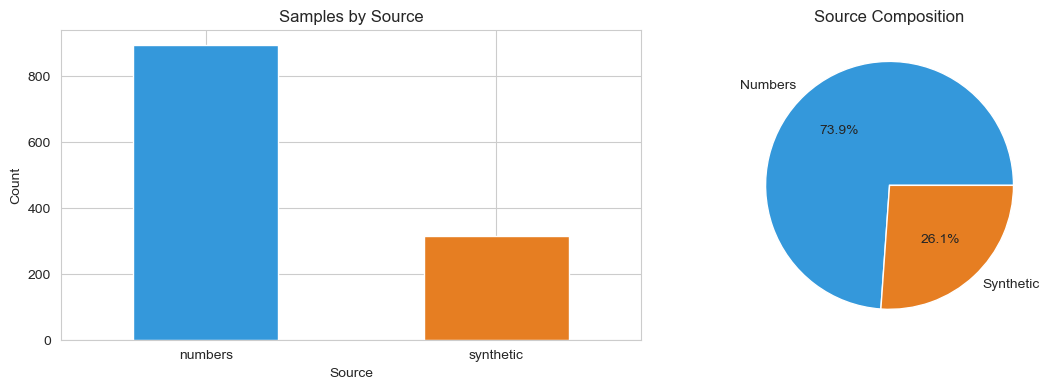

In [3]:
print("=" * 70)
print("SOURCE DISTRIBUTION")
print("=" * 70)

source_counts = df['source'].value_counts()
print(source_counts)
print(f"\nNumbers:   {source_counts.get('numbers', 0)/len(df)*100:.1f}%")
print(f"Synthetic: {source_counts.get('synthetic', 0)/len(df)*100:.1f}%")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

source_counts.plot(kind='bar', ax=ax[0], color=['#3498db', '#e67e22'])
ax[0].set_title('Samples by Source')
ax[0].set_xlabel('Source')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)

source_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                  colors=['#3498db', '#e67e22'], labels=['Numbers', 'Synthetic'])
ax[1].set_title('Source Composition')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Split Distribution by Source

SPLIT DISTRIBUTION BY SOURCE
source  numbers  synthetic
split                     
test         75         48
train       753        221
val          66         47

Percentages:
source  numbers  synthetic
split                     
test       61.0       39.0
train      77.3       22.7
val        58.4       41.6


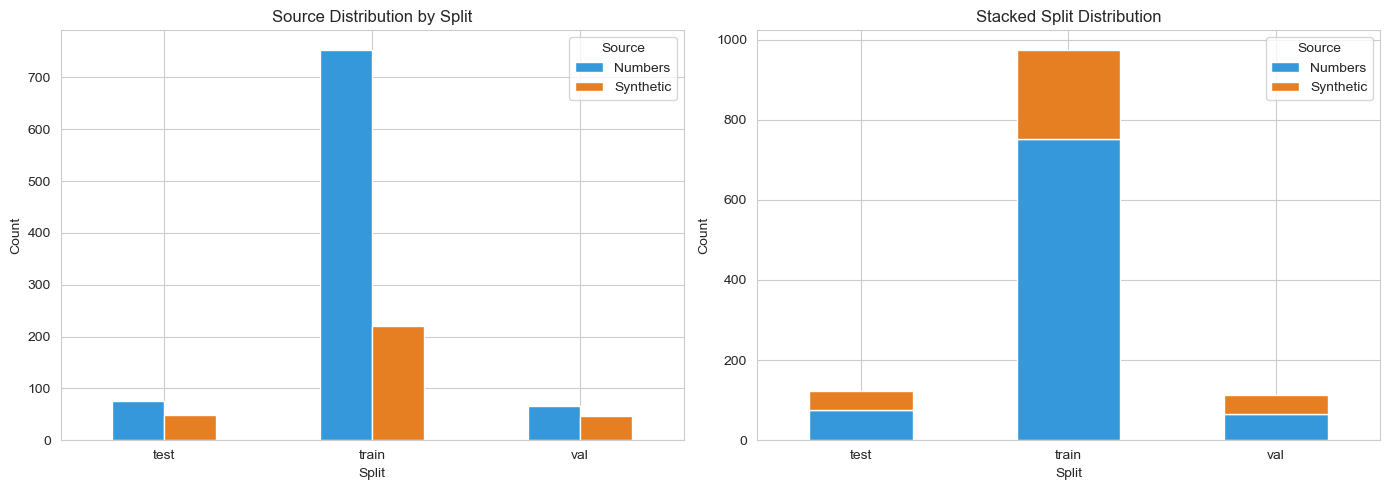

In [4]:
print("=" * 70)
print("SPLIT DISTRIBUTION BY SOURCE")
print("=" * 70)

split_source = pd.crosstab(df['split'], df['source'])
print(split_source)

print("\nPercentages:")
print(split_source.div(split_source.sum(axis=1), axis=0).round(3) * 100)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

split_source.plot(kind='bar', ax=ax[0], color=['#3498db', '#e67e22'])
ax[0].set_title('Source Distribution by Split')
ax[0].set_xlabel('Split')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)
ax[0].legend(title='Source', labels=['Numbers', 'Synthetic'])

split_source.plot(kind='bar', stacked=True, ax=ax[1], color=['#3498db', '#e67e22'])
ax[1].set_title('Stacked Split Distribution')
ax[1].set_xlabel('Split')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title='Source', labels=['Numbers', 'Synthetic'])

plt.tight_layout()
plt.show()

## 4. Field Type Distribution

FIELD TYPE DISTRIBUTION
field_type
price     1029
name       175
header       6
Name: count, dtype: int64

Price: 85.0%
Name:  14.5%
Header: 0.5%

Field Type by Source:
source      numbers  synthetic
field_type                    
header            0          6
name              0        175
price           894        135


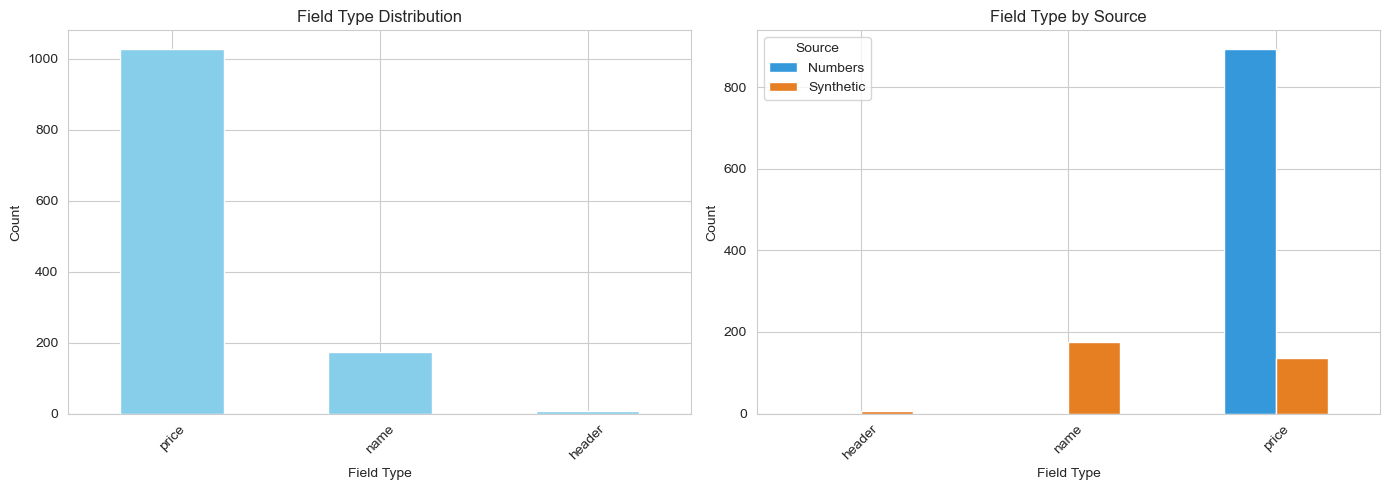

In [5]:
print("=" * 70)
print("FIELD TYPE DISTRIBUTION")
print("=" * 70)

field_counts = df['field_type'].value_counts()
print(field_counts)
print(f"\nPrice: {field_counts.get('price', 0)/len(df)*100:.1f}%")
print(f"Name:  {field_counts.get('name', 0)/len(df)*100:.1f}%")
print(f"Header: {field_counts.get('header', 0)/len(df)*100:.1f}%")

# Cross-tab: field_type vs source
field_source = pd.crosstab(df['field_type'], df['source'])
print("\nField Type by Source:")
print(field_source)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

field_counts.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Field Type Distribution')
ax[0].set_xlabel('Field Type')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=45)

field_source.plot(kind='bar', ax=ax[1], color=['#3498db', '#e67e22'])
ax[1].set_title('Field Type by Source')
ax[1].set_xlabel('Field Type')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(title='Source', labels=['Numbers', 'Synthetic'])

plt.tight_layout()
plt.show()

## 5. Style Leakage Check

**Critical:** Each style should appear in only ONE split.

In [6]:
print("=" * 70)
print("STYLE LEAKAGE CHECK")
print("=" * 70)

train_styles = set(df[df['split'] == 'train']['style_id'].unique())
val_styles = set(df[df['split'] == 'val']['style_id'].unique())
test_styles = set(df[df['split'] == 'test']['style_id'].unique())

print(f"Train styles: {sorted(train_styles)}")
print(f"Val styles:   {sorted(val_styles)}")
print(f"Test styles:  {sorted(test_styles)}")

train_val = train_styles & val_styles
train_test = train_styles & test_styles
val_test = val_styles & test_styles

print(f"\nTrain-Val overlap:  {train_val or '✓ None'}")
print(f"Train-Test overlap: {train_test or '✓ None'}")
print(f"Val-Test overlap:   {val_test or '✓ None'}")

if train_val or train_test or val_test:
    print("\n⚠️  WARNING: Style leakage detected!")
else:
    print("\n✓ PASS: Styles are disjoint")

STYLE LEAKAGE CHECK
Train styles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Val styles:   [np.int64(6), np.int64(7), np.int64(12)]
Test styles:  [np.int64(3), np.int64(7), np.int64(10)]

Train-Val overlap:  {np.int64(12), np.int64(6)}
Train-Test overlap: {np.int64(10), np.int64(3)}
Val-Test overlap:   {np.int64(7)}

⚠️  WARNING: Style leakage detected!


## 6. Text Content Analysis

TEXT CONTENT ANALYSIS
Unique texts: 395
Total samples: 1210
Avg samples per text: 3.1

Text length stats:
  Mean: 5.1 chars
  Min:  1 chars
  Max:  19 chars


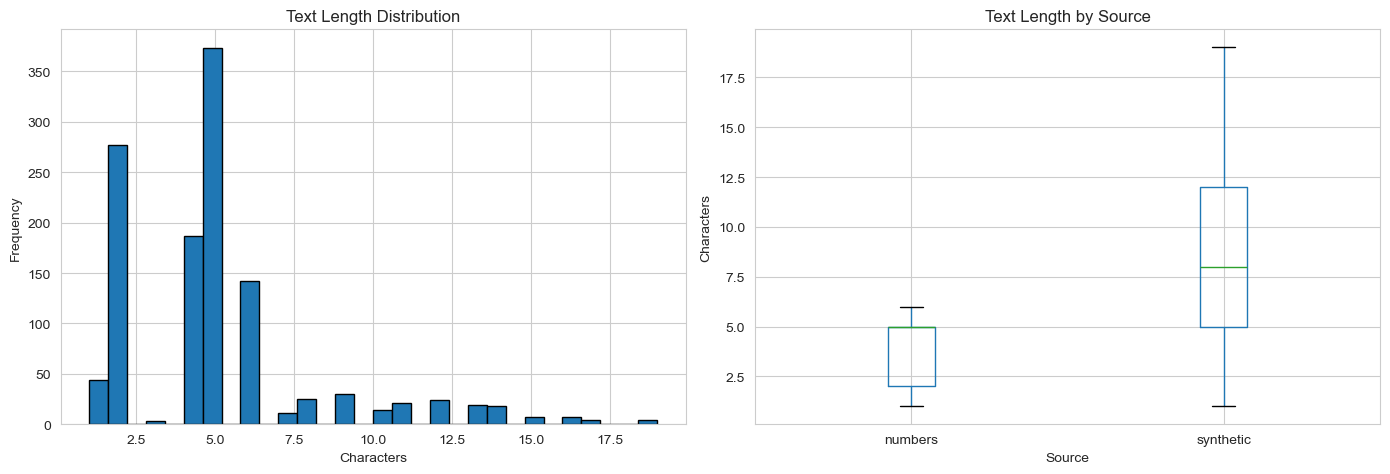

In [7]:
print("=" * 70)
print("TEXT CONTENT ANALYSIS")
print("=" * 70)

# Unique texts
print(f"Unique texts: {df['text'].nunique()}")
print(f"Total samples: {len(df)}")
print(f"Avg samples per text: {len(df)/df['text'].nunique():.1f}")

# Text length distribution
df['text_length'] = df['text'].str.len()
print(f"\nText length stats:")
print(f"  Mean: {df['text_length'].mean():.1f} chars")
print(f"  Min:  {df['text_length'].min()} chars")
print(f"  Max:  {df['text_length'].max()} chars")

# Plot text length by source
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['text_length'].hist(bins=30, ax=ax[0], edgecolor='black')
ax[0].set_title('Text Length Distribution')
ax[0].set_xlabel('Characters')
ax[0].set_ylabel('Frequency')

df.boxplot(column='text_length', by='source', ax=ax[1])
ax[1].set_title('Text Length by Source')
ax[1].set_xlabel('Source')
ax[1].set_ylabel('Characters')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 7. Image Quality Check

In [8]:
print("=" * 70)
print("IMAGE QUALITY CHECK")
print("=" * 70)

missing = []
sizes = []

for idx, row in df.iterrows():
    img_path = dataset_dir / row['crop_path']
    if not img_path.exists():
        missing.append(row['crop_path'])
        continue
    
    img = cv2.imread(str(img_path))
    if img is not None:
        sizes.append(img.shape[:2])

print(f"Total: {len(df)}")
print(f"Missing: {len(missing)}")
print(f"Valid: {len(sizes)}")

if sizes:
    heights, widths = zip(*sizes)
    print(f"\nImage dimensions:")
    print(f"  Avg height: {np.mean(heights):.1f} px")
    print(f"  Avg width:  {np.mean(widths):.1f} px")

if not missing:
    print("\n✓ PASS: All images are valid")

IMAGE QUALITY CHECK
Total: 1210
Missing: 0
Valid: 1210

Image dimensions:
  Avg height: 116.8 px
  Avg width:  311.4 px

✓ PASS: All images are valid


## 8. Visual Samples

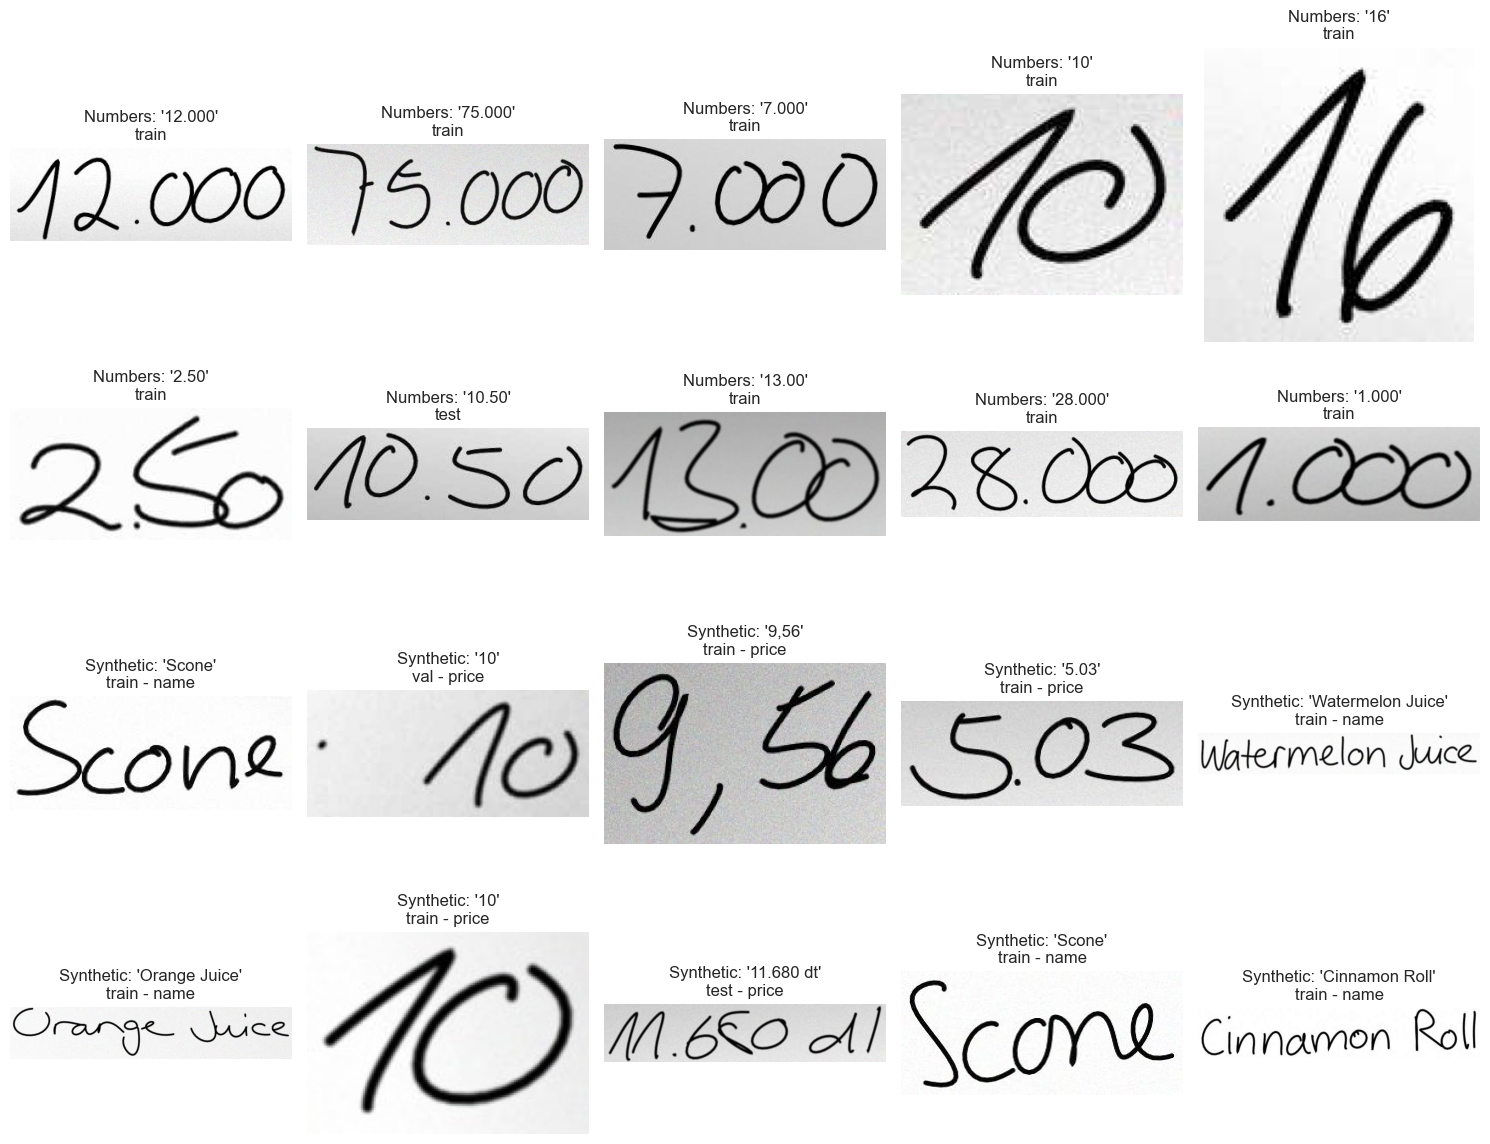

In [9]:
# Show samples from each source
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

# Numbers samples (top 2 rows)
numbers_df = df[df['source'] == 'numbers'].sample(min(10, len(df[df['source'] == 'numbers'])))
for i, (_, row) in enumerate(numbers_df.iterrows()):
    img_path = dataset_dir / row['crop_path']
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Numbers: '{row['text']}'\n{row['split']}")
    axes[i].axis('off')

# Synthetic samples (bottom 2 rows)
synth_df = df[df['source'] == 'synthetic'].sample(min(10, len(df[df['source'] == 'synthetic'])))
for i, (_, row) in enumerate(synth_df.iterrows(), start=10):
    img_path = dataset_dir / row['crop_path']
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Synthetic: '{row['text']}'\n{row['split']} - {row['field_type']}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 9. Dataset Summary

In [10]:
print("=" * 70)
print("MIXED DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal samples: {len(df)}")
print(f"\nSource composition:")
for source in ['numbers', 'synthetic']:
    count = len(df[df['source'] == source])
    print(f"  {source.capitalize():10s}: {count:4d} ({count/len(df)*100:.1f}%)")

print(f"\nSplit distribution:")
for split in ['train', 'val', 'test']:
    count = len(df[df['split'] == split])
    print(f"  {split.capitalize():5s}: {count:4d} ({count/len(df)*100:.1f}%)")

print(f"\nField type distribution:")
for field_type in df['field_type'].unique():
    count = len(df[df['field_type'] == field_type])
    print(f"  {field_type.capitalize():7s}: {count:4d} ({count/len(df)*100:.1f}%)")

print(f"\n✓ Mixed dataset ready for training!")
print(f"\nNext steps:")
print(f"  python ../../training/train_synthetic.py \\")
print(f"    --dataset_dir dataset_mixed \\")
print(f"    --base_checkpoint ../../models/trocr_menu_v1_epoch2 \\")
print(f"    --output_model_dir ../../models/trocr_menu_v1_digits_v2 \\")
print(f"    --max_epochs 3 --lr 1e-5")

MIXED DATASET SUMMARY

Total samples: 1210

Source composition:
  Numbers   :  894 (73.9%)
  Synthetic :  316 (26.1%)

Split distribution:
  Train:  974 (80.5%)
  Val  :  113 (9.3%)
  Test :  123 (10.2%)

Field type distribution:
  Price  : 1029 (85.0%)
  Name   :  175 (14.5%)
  Header :    6 (0.5%)

✓ Mixed dataset ready for training!

Next steps:
  python ../../training/train_synthetic.py \
    --dataset_dir dataset_mixed \
    --base_checkpoint ../../models/trocr_menu_v1_epoch2 \
    --output_model_dir ../../models/trocr_menu_v1_digits_v2 \
    --max_epochs 3 --lr 1e-5
